# MeteoScreening `SWC_FF1_0.05_1` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `SWC_FF1_0.05_1` &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025  
**Cross-check**: the other depths of the same soil profile (`0.1`, `0.2`, `0.3`, `0.5` m) and the screened precipitation product — see *Cross-check* below  
**Derived from**: diive notebook template `DatabaseInfluxStepwiseMeteoScreening.ipynb` (version `9`, 15 Jul 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil water content from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → cross-check against the rest of the soil profile → screen on high-res data (`diive`) → resample to 30MIN → validate against the profile → upload.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

**This notebook is the pattern for the other depths.** `0.05` is only the shallowest sensor of the FF1 profile; `0.1`, `0.2`, `0.3` and `0.5` are screened by copies of this notebook. Copy it, change `DEPTH` in *User settings*, and **re-derive `REMOVE_DATES` from that depth's own evidence** — the removal windows below belong to the 5 cm sensor and must not be carried over blindly. See the closing note *Reusing this notebook for the other depths*.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting the timestamp right is the one thing that must not go wrong, because the day/night split during screening — and the value written back to the DB — both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload. Here is the full round-trip, all handled for you:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on correct local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp in the DB. **`TIMEZONE_OFFSET_TO_UTC_HOURS` must match the timezone the raw data was logged in** (e.g. `1` for CET winter time) and must be the same value everywhere. This notebook prints the timestamps right after download and right after the verification download so you can confirm they look correct.

Everything in the *Cross-check* section works on `TIMESTAMP_END` as downloaded. The precipitation product read there is stored on `TIMESTAMP_MID` and is shifted to `TIMESTAMP_END` before use.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening (not used for soil moisture — see *Outlier detection*).

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. **This is the only place to change when screening another depth.**
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `SWC` for soil water content.
- `COMPANION_DEPTHS`: the other depths of the same profile, used as the cross-check reference. They are *not* screened here.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see the *Timestamp convention* section above. Must match how the raw data was logged (e.g. `1` for CET winter time).
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: aggregation used when resampling. Soil water content is a **state**, so `'mean'` — never `'sum'`.

**Cross-check**
- `PREC_PRODUCT` / `PREC_COL`: the screened precipitation product, used to test whether the sensor still *responds* to rain. Produced by [`30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb`](../../30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb).
- `FIELDBOOK`: the GIN fieldbook export, read directly here so that every candidate period is adjudicated against the site record in the notebook rather than by hand.

**Parameter help**
- `SHOW_PARAM_HELP`: set `True` to print the full docstring (all parameters) of each screening method right before it runs. Leave `False` for a clean, concise notebook.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# Verified 21 Jul 2026 against measurement SWC of bucket ch-lae_raw: the FF1 profile
# holds five depths (0.05, 0.1, 0.2, 0.3, 0.5), all TEROS 12, all starting
# 2020-04-10. (The older M5 profile, SWC_M5_*, ends the same day and is a
# different, now-trashed sensor set - see the closing note. The FF3 profile
# starts only in 2026 and is out of scope here.)
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.05'  # <-- the only setting to change when screening another depth
REPL = '1'  # replicate
FIELD = f'SWC_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'SWC'

# The rest of the profile: the cross-check reference. Screened by their own notebooks.
COMPANION_DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
COMPANION_FIELDS = [f'SWC_{PROFILE}_{d}_{REPL}' for d in COMPANION_DEPTHS if d != DEPTH]

# --- Time range to screen ---
# Raw resolution is 10MIN until the 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records (~3 min to download). The profile starts
# 2020-04-10; asking for 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil water content is a state variable, never summed

# --- Cross-check: the screened precipitation product (30_PRODUCTS/08) ---
PREC_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                r'\workflow\10_METEO\30_PRODUCTS'
                r'\08_METEO_PREC_GAPFILLED_2004-2025.parquet')
PREC_COL = 'PREC_TOT_T1_47_1'

# --- Cross-check: the GIN fieldbook export (site record) ---
FIELDBOOK = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
             r'\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv')

# --- Physical range of soil water content at this site, in % (volumetric) ---
# Used by the absolute-limits test and by the candidate scan. 0 is the hard
# physical floor; 60 sits above any plausible porosity for this soil and is
# far above the highest value ever measured in this profile (40.6%).
SWC_MIN, SWC_MAX = 0, 60

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:            {FIELD}')
print(f'Cross-check against:           {COMPANION_FIELDS}')
print(f'Source bucket (raw data):      {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:            SWC_FF1_0.05_1
Cross-check against:           ['SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']
Source bucket (raw data):      ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra
from diive.core.times.times import detect_freq_groups  # the same grouping the screening uses internally

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-21 21:52:45
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement SWC of bucket ch-lae_raw:

> Found 16 fields in measurement SWC of bucket ch-lae_raw.

['SWC_FF1_0.05_1',
 'SWC_FF1_0.1_1',
 'SWC_FF1_0.2_1',
 'SWC_FF1_0.3_1',
 'SWC_FF1_0.5_1',
 'SWC_FF3_0.05_1',
 'SWC_FF3_0.05_2',
 'SWC_FF3_0.1_1',
 'SWC_FF3_0.2_1',
 'SWC_FF3_0.3_1',
 'SWC_FF3_0.4_1',
 'SWC_FF3_0.5_1',
 'SWC_M5_0.05_1',
 'SWC_M5_0.1_1',
 'SWC_M5_0.2_1',
 'SWC_M5_0.3_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** — this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.05_1'] from measurements ['SWC'], data
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 39.4 s
Wall time: 55.8 s


### Inspect downloaded data

In [7]:
data_simple

,SWC_FF1_0.05_1
TIMESTAMP_END,
2020-04-10 15:00:00,30.90000
2020-04-10 15:10:00,30.90000
2020-04-10 15:20:00,30.90000
2020-04-10 15:30:00,30.90000
2020-04-10 15:40:00,30.90000
...,...
2025-12-31 23:56:00,29.51567
2025-12-31 23:57:00,29.54534
2025-12-31 23:58:00,29.51160


In [8]:
assigned_measurements

{'SWC_FF1_0.05_1': 'SWC'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')

Data available for: ['SWC_FF1_0.05_1']


### Verify download timestamps
Confirm the timestamps look right: they should be in **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the **end** of each averaging interval. The DB itself stores UTC — `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

SWC_FF1_0.05_1: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### The raw record has two time resolutions
This variable is **10MIN until the March 2021 logger rebuild and 1MIN after it** (fieldbook 2021-03-24/26: the FF1 logger box was rebuilt and a new program uploaded; the sensors themselves were only reconnected, not replaced). The database keeps both eras under the same field name, so a single download returns a series whose spacing changes partway through.

`StepwiseMeteoScreeningDb` handles this itself, and it is worth knowing exactly how, because it shapes what the outlier tests see:

- it groups the records by detected resolution and **drops any group holding less than 0.2%** of the records (below, the handful of 2/3/5/6-minute stragglers from the April 2024 bus failure);
- it **upsamples the coarser era onto the finest grid**, back-filling each 10MIN value across the ten 1MIN slots it covers (the timestamp is `TIMESTAMP_END`, so the fill runs backwards);
- only then does it convert to `TIMESTAMP_MID` and start screening.

Two consequences for the tests further down: the 10MIN era arrives as **runs of ten identical values**, so any test built on *increments* sees nine zeros out of ten there and is not comparable across the two eras; and a window given in *records* covers the same wall-clock time in both eras, which is why windows below are written as `60 * 24 * ...`.

The cell below reports the groups so you can see the split for yourself rather than trust this paragraph.

In [11]:
_freqgroups = detect_freq_groups(index=data_detailed[FIELD].index)
_counts = _freqgroups.value_counts()
print(f'{"freq [s]":>10s} {"records":>10s} {"share":>8s}   first record        last record')
for _f in _counts.index:
    _ix = _freqgroups[_freqgroups == _f].index
    _share = len(_ix) / len(_freqgroups) * 100
    _kept = 'used' if _share > 0.2 else 'dropped by diive (< 0.2%)'
    print(f'{_f:10.0f} {len(_ix):10d} {_share:7.2f}%   {_ix[0]}  {_ix[-1]}   {_kept}')

  freq [s]    records    share   first record        last record
        60    2452428   97.97%   2021-03-26 15:23:00  2026-01-01 00:00:00   used
       600      50079    2.00%   2020-04-10 15:00:00  2021-03-24 09:50:00   used
       180         11    0.00%   2024-04-04 12:01:00  2024-04-08 21:12:00   dropped by diive (< 0.2%)
       120          9    0.00%   2024-04-06 03:50:00  2024-04-08 02:41:00   dropped by diive (< 0.2%)
       360          3    0.00%   2024-04-05 23:34:00  2024-04-05 23:46:00   dropped by diive (< 0.2%)
       300          3    0.00%   2024-04-09 00:01:00  2024-04-09 00:11:00   dropped by diive (< 0.2%)


### Plot downloaded high-res data

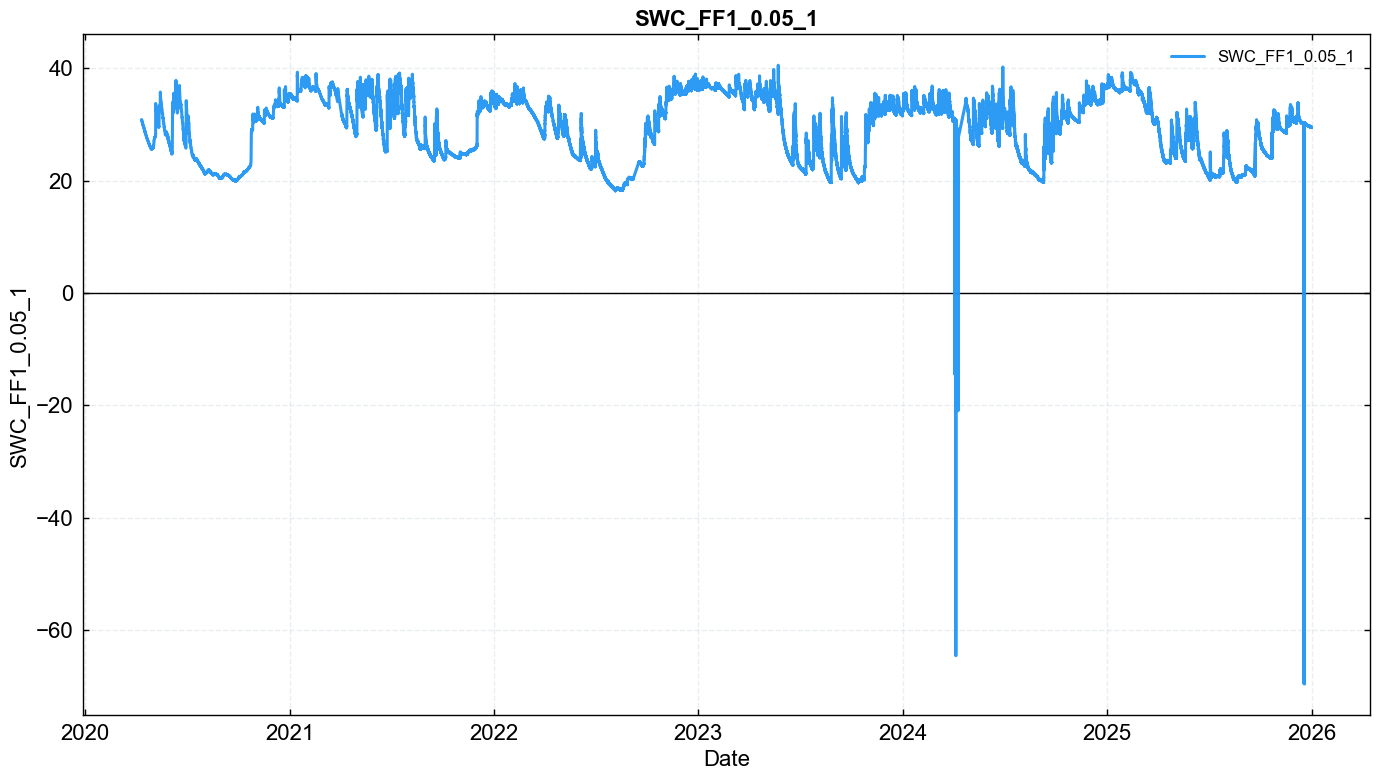

In [12]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## 🔍 Cross-check against the rest of the soil profile
Soil water content has no external reference — no weather service measures the soil at this plot. What it does have is **four other sensors in the same profile**, 5 to 50 cm below the same square metre of forest floor, plus the site's own **precipitation** record. Together those answer the question a single soil sensor cannot answer about itself: *is it still measuring the soil?*

The two failure modes worth separating:

- **it stops reporting** — communication failures, power loss. Loud and easy: gaps and impossible values, which the screening tests below remove.
- **it stops being coupled to the soil** — the soil shrinks away from the prongs in a dry summer, a root grows into the measurement volume, the backfill settles. This one is **quiet**: the series stays inside the physical range, stays smooth, and drifts plausibly. No statistical outlier test can see it. What gives it away is that the sensor no longer *responds*: rain falls, every deeper sensor wets up, and this one does not move.

> **What this can and cannot tell you.** The depths are not replicates — a 5 cm sensor legitimately dries faster, wets first, and swings harder than a 50 cm sensor, so the levels differ and the correlations are far from 1. What is *not* legitimate is a shallow sensor sitting still while the layers underneath it wet up: water reaches 20 cm by passing through 5 cm first. Use the section to *find candidate periods*, then confirm each one against the fieldbook before putting it in `REMOVE_DATES`.

*Sources: the FF1 soil profile (this site) and the screened precipitation product of notebook `30_PRODUCTS/08`.*

In [13]:
def to_30min_mean(series: pd.Series, min_coverage: float = 0.5,
                  max_step: pd.Timedelta = pd.Timedelta('10min')) -> pd.Series:
    """Resample a high-res series to 30MIN means on the end-labelled grid.

    Uses the same end-labelled convention as the database: the period ending at T
    holds the records in (T-30min, T].

    A plain record count cannot decide whether a half hour is well covered here,
    because the raw spacing changes over the record (10MIN before the 2021 logger
    rebuild, 1MIN after) - three records mean full coverage in the first era and
    a 90% gap in the second. Each record is therefore credited with the time it
    represents, i.e. the distance back to the previous record, capped at
    *max_step* so the first record after a long gap cannot claim the whole gap.
    A half hour is returned only when the records present cover at least
    *min_coverage* of it, otherwise NaN - so a gap never masquerades as data.
    """
    if series.empty:
        raise ValueError('to_30min_mean got an empty series')
    spacing = series.index.to_series().diff()
    step = spacing.median()
    if pd.isna(step) or step > pd.Timedelta('30min'):
        raise ValueError(f'cannot resample to 30MIN from a {step} series')
    represented = spacing.clip(upper=max_step).fillna(step)
    grouper = pd.Grouper(freq='30min', label='right', closed='right')
    means = series.groupby(grouper).mean()
    coverage = represented.groupby(grouper).sum() / pd.Timedelta('30min')
    return means.where(coverage >= min_coverage)


def report_blocks(index, label: str, maxgap: str = '1D', note=None):
    """Group a DatetimeIndex of hits into contiguous blocks and print them
    ready to paste into REMOVE_DATES."""
    if len(index) == 0:
        print(f'{label}: none')
        return
    hits = pd.Series(index=pd.DatetimeIndex(index), data=1).sort_index()
    grp = (hits.index.to_series().diff() > pd.Timedelta(maxgap)).cumsum()
    print(f'{label}: {grp.nunique()} period(s)')
    for _, blk in hits.groupby(grp):
        comment = '' if note is None else f'  # {note(blk.index)}'
        print(f"    ['{blk.index[0]:%Y-%m-%d %H:%M:%S}', '{blk.index[-1]:%Y-%m-%d %H:%M:%S}'],{comment}")

#### Negative control
`to_30min_mean` would happily return a series of NaN if handed something that is not high-resolution — silently producing an "empty" comparison that looks like a data gap. Prove it raises instead.

In [14]:
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'already coarser than 30MIN')]:
    try:
        to_30min_mean(_bad)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - to_30min_mean accepted {_why}')

PASSED - empty series raises: to_30min_mean got an empty series
PASSED - already coarser than 30MIN raises: cannot resample to 30MIN from a 0 days 01:00:00 series


### Download the companion depths
The other four depths, over the same period and from the same raw bucket. They are reduced to 30MIN means immediately and the high-resolution frames are dropped again — the cross-check needs half-hourly means, not four more million-record frames in memory.

⏳ This is the slowest cell in the notebook (four variables at raw resolution, several minutes).

In [15]:
%%time
_comp_simple, _comp_detailed, _comp_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=COMPANION_FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

# Target first, then the companions ordered by depth: one 30MIN frame for the whole profile.
prof = pd.DataFrame({FIELD: to_30min_mean(data_detailed[FIELD][FIELD].dropna())})
for _v in COMPANION_FIELDS:
    if _v not in _comp_detailed:
        print(f'(!) {_v} has no data in this period and is left out of the cross-check.')
        continue
    prof[_v] = to_30min_mean(_comp_detailed[_v][_v].dropna())
prof = prof.sort_index()
COMPANIONS = [c for c in prof.columns if c != FIELD]

del _comp_simple, _comp_detailed  # the high-res companion frames are not needed again

assert COMPANIONS, '(!) no companion depth available - the cross-check below cannot run'
print(f'profile frame: {prof.shape[0]} half-hours, {prof.index[0]} -> {prof.index[-1]}')
print(f'target: {FIELD} | companions: {COMPANIONS}')

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 
'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1'] from measurements ['SWC'], data version ['raw'], between 
2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 4 variables:

profile frame: 100387 half-hours, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
target: SWC_FF1_0.05_1 | companions: ['SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']
CPU times: total: 2min 44s
Wall time: 3min 51s


### Level, coverage and correlation
First the plain description: how much data each sensor has, where it sits, and how strongly the depths move together. Correlations between depths are expected to be **high but not near-perfect** (r ≈ 0.7-0.9 on daily means) and to *decrease with depth separation* — the 5 cm and 50 cm sensors measure genuinely different things.

In [16]:
print('data coverage per year (fraction of 30MIN periods with a value):')
display(prof.notna().groupby(prof.index.year).mean().round(3))

print('\nlevel and spread over the whole period [% VWC]:')
display(prof.describe().round(2))

print('\ncorrelation of daily means:')
display(prof.resample('D').mean().corr().round(3))

data coverage per year (fraction of 30MIN periods with a value):


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
TIMESTAMP_END,,,,,
2020,1.000,1.000,1.000,1.000,1.000
2021,0.977,0.977,0.977,0.977,0.977
2022,0.972,0.972,0.972,0.972,0.972
2023,0.998,0.998,0.998,0.998,0.998
2024,0.948,0.950,0.951,0.272,0.953
2025,1.000,1.000,1.000,0.828,1.000
2026,1.000,1.000,1.000,1.000,1.000



level and spread over the whole period [% VWC]:


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
count,98538.00,98583.00,98585.00,83666.00,98624.00
mean,29.52,29.77,31.23,27.15,24.12
std,5.45,5.26,4.11,3.51,2.77
min,-16.90,18.20,20.37,19.91,3.96
25%,24.67,25.29,27.77,23.65,20.71
50%,30.64,31.11,32.83,28.48,25.35
75%,34.08,33.53,34.27,29.51,26.25
max,39.71,54.26,39.03,36.41,31.75



correlation of daily means:


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
SWC_FF1_0.05_1,1.000,0.897,0.893,0.716,0.847
SWC_FF1_0.1_1,0.897,1.000,0.928,0.754,0.849
SWC_FF1_0.2_1,0.893,0.928,1.000,0.891,0.879
SWC_FF1_0.3_1,0.716,0.754,0.891,1.000,0.853
SWC_FF1_0.5_1,0.847,0.849,0.879,0.853,1.000


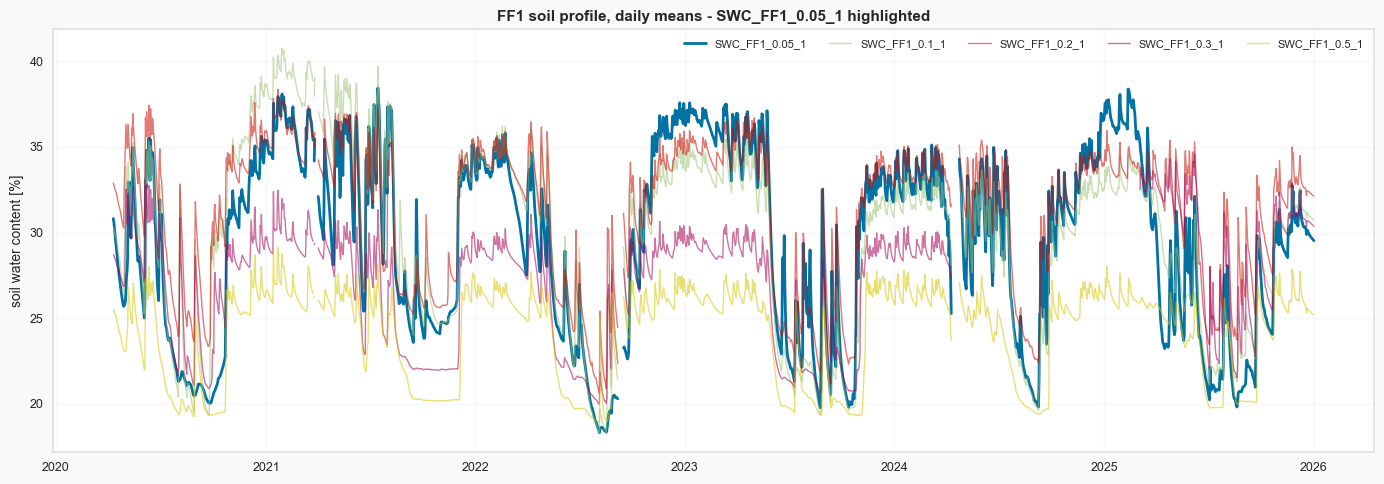

In [17]:
_daily = prof.resample('D').mean()
fig, ax = plt.subplots(figsize=(14, 5))
for _c in prof.columns:
    _lw, _alpha = (2.0, 1.0) if _c == FIELD else (1.0, .55)
    ax.plot(_daily.index, _daily[_c], label=_c, lw=_lw, alpha=_alpha)
ax.set_ylabel('soil water content [%]')
ax.set_title(f'FF1 soil profile, daily means - {FIELD} highlighted')
ax.legend(ncol=len(prof.columns), fontsize=8)
plt.tight_layout()
plt.show()

### Does the target still move with the profile?
Levels differ by depth, so compare **changes** rather than values: the daily change of the target against the daily change of the rest of the profile, correlated in a rolling 30-day window. A well-coupled sensor keeps this high (r ≈ 0.8-0.9); a sensor that has lost contact with the soil keeps producing smooth, in-range values whose *changes* have nothing to do with what the soil is doing, and the rolling correlation collapses.

This is the diagnostic that found the 2020 fault documented below — nothing in the values themselves looks wrong there.

rolling 30-day correlation of daily increments, target vs profile mean:


,count,mean,std,min,25%,50%,75%,max
TIMESTAMP_END,,,,,,,,
2020,246.0,0.57,0.37,-0.36,0.16,0.77,0.88,0.97
2021,365.0,0.82,0.14,0.38,0.74,0.87,0.92,0.99
2022,365.0,0.83,0.14,-0.06,0.76,0.86,0.93,0.99
2023,365.0,0.83,0.14,0.29,0.77,0.88,0.93,0.99
2024,343.0,0.90,0.10,0.56,0.87,0.94,0.97,0.99
2025,365.0,0.84,0.13,0.28,0.77,0.86,0.94,0.99
2026,1.0,0.96,NaN,0.96,0.96,0.96,0.96,0.96


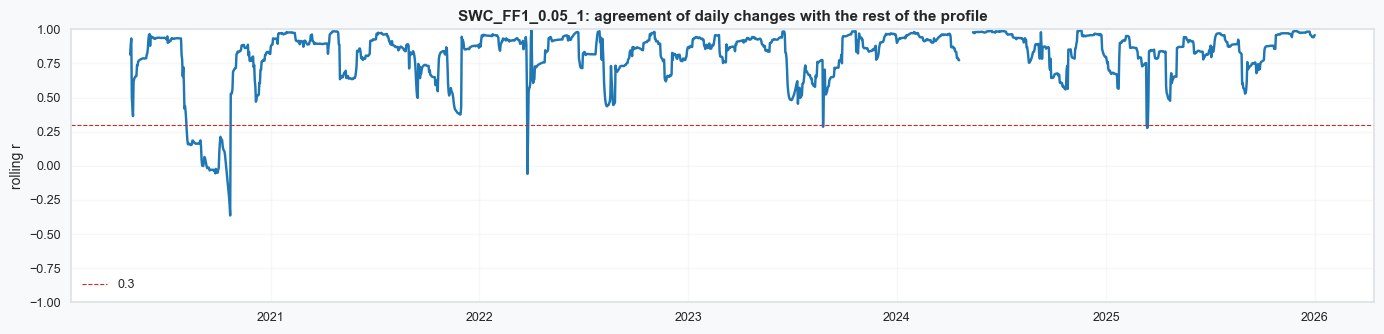

ROLLING AGREEMENT BELOW 0.3: 4 period(s)
    ['2020-08-07 00:00:00', '2020-10-22 00:00:00'],  # 77 day(s)
    ['2022-03-26 00:00:00', '2022-03-27 00:00:00'],  # 2 day(s)
    ['2023-08-25 00:00:00', '2023-08-25 00:00:00'],  # 1 day(s)
    ['2025-03-14 00:00:00', '2025-03-15 00:00:00'],  # 2 day(s)


In [18]:
_d_target = _daily[FIELD].diff()
_d_others = _daily[COMPANIONS].mean(axis=1).diff()
rollcorr = _d_target.rolling(30, min_periods=20).corr(_d_others)

print('rolling 30-day correlation of daily increments, target vs profile mean:')
display(rollcorr.groupby(rollcorr.index.year).describe().round(2))

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(rollcorr.index, rollcorr, color='tab:blue')
ax.axhline(0.3, color='tab:red', lw=.8, ls='--', label='0.3')
ax.set_ylim(-1, 1)
ax.set_ylabel('rolling r')
ax.set_title(f'{FIELD}: agreement of daily changes with the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

report_blocks(rollcorr[rollcorr < 0.3].index, 'ROLLING AGREEMENT BELOW 0.3', maxgap='3D',
              note=lambda ix: f'{len(ix)} day(s)')

### Does the target still respond to rain?
The sharpest test for the shallowest sensor. For every day with more than 10 mm of precipitation, take the rise of each depth's daily mean over the following two days, and divide the target's rise by the profile mean's. A shallow sensor should give a **ratio at or above 1** — water arrives at 5 cm first. A ratio near **0** while the deeper sensors rise by several percent VWC is physically impossible and means the probe is no longer coupled to the soil.

The summer table is the one to read: that is when soil shrinkage opens gaps around the prongs.

In [19]:
prec = pd.read_parquet(PREC_PRODUCT)[PREC_COL]
prec.index = prec.index + pd.Timedelta('15min')  # TIMESTAMP_MID -> TIMESTAMP_END, as used here
_shared = prof.index.intersection(prec.index)
assert len(_shared) > 0.5 * len(prof), (
    '(!) precipitation product does not line up with the profile - check the timestamp shift')
print(f'precipitation: {prec.index[0]} -> {prec.index[-1]}, '
      f'{len(_shared) / len(prof) * 100:.1f}% of the profile period covered')

_dprec = prec.reindex(prof.index).resample('D').sum(min_count=40)
_events = _dprec[_dprec > 10].index

_rows = []
for _day in _events:
    _before = _daily.loc[:_day - pd.Timedelta('1D')].tail(1)
    _after = _daily.loc[_day:_day + pd.Timedelta('2D')]
    if _before.empty or _after.empty:
        continue
    _resp = _after.max() - _before.iloc[0]
    _resp['PREC'] = _dprec.loc[_day]
    _rows.append(_resp.rename(_day))
resp = pd.DataFrame(_rows)
resp['RATIO'] = resp[FIELD] / resp[COMPANIONS].mean(axis=1)
print(f'\n{len(resp)} rain events > 10 mm/day in the screened period')

print('\nmedian rise per depth [% VWC] after a > 10 mm day, per year:')
display(resp.groupby(resp.index.year).median().round(2))

print('\nmedian response ratio (target / profile mean), all events and summer only:')
_summer = resp[resp.index.month.isin([7, 8, 9, 10])]
display(pd.DataFrame({'all events': resp['RATIO'].groupby(resp.index.year).median(),
                      'Jul-Oct': _summer['RATIO'].groupby(_summer.index.year).median(),
                      'n events': resp['RATIO'].groupby(resp.index.year).size()}).round(2))

precipitation: 2004-01-01 00:30:00 -> 2026-01-01 00:00:00, 100.0% of the profile period covered

198 rain events > 10 mm/day in the screened period

median rise per depth [% VWC] after a > 10 mm day, per year:


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1,PREC,RATIO
2020,1.16,2.95,2.11,2.06,0.69,14.4,0.77
2021,1.95,2.00,1.62,1.67,1.21,13.8,1.12
2022,1.17,1.57,1.45,1.32,1.43,13.9,0.90
2023,2.93,1.31,1.44,0.70,0.29,14.6,1.66
2024,2.32,1.73,1.92,0.94,0.59,15.5,1.70
2025,2.07,1.42,2.25,3.04,1.09,15.7,1.14



median response ratio (target / profile mean), all events and summer only:


,all events,Jul-Oct,n events
2020,0.77,0.04,20
2021,1.12,1.26,36
2022,0.90,1.50,30
2023,1.66,2.61,32
2024,1.70,1.74,39
2025,1.14,0.97,41


### Candidate periods for `REMOVE_DATES`
Four scans, each for a different failure mode. All of them produce **candidates only** — check each against the fieldbook and against the plots above before removing anything.

In [20]:
_target_hires = data_detailed[FIELD][FIELD].dropna()

report_blocks(_target_hires[(_target_hires < SWC_MIN) | (_target_hires > SWC_MAX)].index,
              f'OUTSIDE THE PHYSICAL RANGE [{SWC_MIN}, {SWC_MAX}] %', maxgap='1D',
              note=lambda ix: f'{len(ix)} record(s)')

_cov = prof[FIELD].notna().resample('D').mean()
report_blocks(_cov[_cov < 0.9].index, 'DAILY COVERAGE BELOW 90%', maxgap='2D',
              note=lambda ix: f'{len(ix)} day(s)')

report_blocks(rollcorr[rollcorr < 0.3].index, 'NOT MOVING WITH THE PROFILE (rolling r < 0.3)',
              maxgap='3D', note=lambda ix: f'{len(ix)} day(s)')

# A stuck sensor repeats one value. Runs are measured in *time*, not in records,
# because a record means ten minutes in the early era and one minute in the late one.
# Stored precision also changed: until the logger software update of 21 Apr 2020 the
# values arrived in steps of 0.1%, so during a slow dry-down they legitimately hold the
# same rounded value for hours. The threshold below is therefore loose, and the maxima
# printed with it are the more informative numbers.
_runs = (_target_hires != _target_hires.shift()).cumsum()
_spans = _target_hires.groupby(_runs).apply(lambda x: x.index[-1] - x.index[0])
_ends = _target_hires.groupby(_runs).apply(lambda x: x.index[-1])
_sizes = _target_hires.groupby(_runs).size()
_stuck = _spans[_spans >= pd.Timedelta('24h')]
print(f'IDENTICAL-VALUE RUNS LASTING >= 24 h: {len(_stuck)}')
for _g in _stuck.index:
    print(f"    ['{_ends.loc[_g] - _spans.loc[_g]:%Y-%m-%d %H:%M:%S}', "
          f"'{_ends.loc[_g]:%Y-%m-%d %H:%M:%S}'],  # {_sizes.loc[_g]} identical records")
for _label, _mask in [('whole record', _spans.notna()),
                      ('1MIN era only', _ends > pd.Timestamp('2021-03-27'))]:
    _sub = _spans[_mask]
    print(f'   longest identical-value run, {_label}: {_sub.max()} '
          f'(ending {_ends.loc[_sub.idxmax()]})')

print('\n(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)')

OUTSIDE THE PHYSICAL RANGE [0, 60] %: 3 period(s)
    ['2024-04-03 05:20:00', '2024-04-03 14:53:00'],  # 3 record(s)
    ['2024-04-05 06:07:00', '2024-04-09 00:20:00'],  # 17 record(s)
    ['2025-12-18 17:45:00', '2025-12-19 10:39:00'],  # 7 record(s)
DAILY COVERAGE BELOW 90%: 6 period(s)
    ['2021-03-24 00:00:00', '2021-04-02 00:00:00'],  # 10 day(s)
    ['2022-09-06 00:00:00', '2022-09-16 00:00:00'],  # 11 day(s)
    ['2023-06-15 00:00:00', '2023-06-15 00:00:00'],  # 1 day(s)
    ['2024-04-03 00:00:00', '2024-04-23 00:00:00'],  # 20 day(s)
    ['2024-06-29 00:00:00', '2024-07-01 00:00:00'],  # 3 day(s)
    ['2024-10-16 00:00:00', '2024-10-16 00:00:00'],  # 1 day(s)
NOT MOVING WITH THE PROFILE (rolling r < 0.3): 4 period(s)
    ['2020-08-07 00:00:00', '2020-10-22 00:00:00'],  # 77 day(s)
    ['2022-03-26 00:00:00', '2022-03-27 00:00:00'],  # 2 day(s)
    ['2023-08-25 00:00:00', '2023-08-25 00:00:00'],  # 1 day(s)
    ['2025-03-14 00:00:00', '2025-03-15 00:00:00'],  # 2 day(s)
IDENTIC

### Adjudicate the candidates against the fieldbook
A candidate period means nothing until it is matched against what happened at the site. The GIN
fieldbook export is read here directly, so the adjudication written up below can be re-run and
challenged rather than taken on trust.

Filtering on the SWC device tags alone would miss most of it: the entries that explain these periods
are power-supply and logger entries carrying no soil device at all. The filter therefore also takes
anything at this profile's location, its logger/DAQ, or a free-text mention of soil, power, logger
or SDI-12.

In [21]:
import html
import re

_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'


def _plaintext(s):
    """GIN stores the entry body as HTML; strip the tags and entities."""
    return re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()


_fb['text'] = _fb['Text'].map(_plaintext)
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['text'].str.contains(r'soil|SWC|Teros|SDI|power|logger', case=False, na=False))
fb = (_fb[_mask & _fb['date'].between(START, STOP)]
      .drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))
assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f'fieldbook: {len(_fb)} entries total, '
      f'{len(fb)} relevant to {PROFILE} within the screened period')


def fieldbook_near(start, stop=None, days: int = 3, maxchars: int = 220):
    """Print the fieldbook entries within *days* of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f'   (no fieldbook entry within +/-{days} days)')
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} {r['Event Tag']:<12s} {r['text'][:maxchars]}")

fieldbook: 2102 entries total, 129 relevant to FF1 within the screened period


In [22]:
# One entry per candidate period found by the scans above. Keep this list in sync with
# them when re-running for another depth - it is the record of what was adjudicated.
CANDIDATES = [
    ('2020-08-01', '2020-10-24', 'no response to rain (decoupled probe)'),
    ('2021-03-24', '2021-04-02', 'coverage gap'),
    ('2022-09-06', '2022-09-16', 'coverage gap'),
    ('2023-06-15', '2023-06-15', 'coverage gap'),
    ('2024-04-03', '2024-04-23', 'coverage gap + out-of-range values'),
    ('2024-06-29', '2024-07-01', 'coverage gap'),
    ('2024-10-16', '2024-10-16', 'coverage gap'),
    ('2025-12-18', '2025-12-19', 'out-of-range values'),
]
for _start, _stop, _why in CANDIDATES:
    print(f'\n--- {_start} -> {_stop}  ({_why})')
    fieldbook_near(_start, _stop, days=3)


--- 2020-08-01 -> 2020-10-24  (no response to rain (decoupled probe))
   2020-10-20 CLEAN        Cleaned the logger box for the iDL_T1_47_1 from millions of alive and death flies and leftovers from wild bees nest. Checked the box for leakage where all these animals could gotten into the box and sealed open cable fee

--- 2021-03-24 -> 2021-04-02  (coverage gap)
   2021-03-24 HW_MOD       Installed new box with datalogger und multiplexer
   2021-03-24 TRASHED      Device trashed
   2021-03-24 HW_MOD       Shutdown the FF1 logger and all components for reconstruction of the logger box. We kept the naming of all variable where we didn't replaced the sensors by new sensor (type). Since we never added the location "box" to th
   2021-03-24 ADD          Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_1
   2021-03-24 ADD          Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_2
   2021-03

#### How to read the candidate list

The outcome for `SWC_FF1_0.05_1`, read off the cell above:

- **Out of physical range** — 27 records, all of them isolated single-minute negative values
  (−14.4, −19.8, −20.9, −64.6, −69.6 …), never a run. They appear on the other depths at the same
  minutes with their own fixed negative values, which is what a failed SDI-12 read looks like once
  it has been pushed through each sensor's own calibration. The fieldbook explains why it is a fixed
  number rather than a gap: on 2020-04-10, when this profile was first logged, the technician
  considered updating the CR1000 firmware because *"firmware from S29 on provide NAN support on all
  the elements of array when measuring SDI12"* and decided against it. Without NaN support a failed
  read is stored as a number. The two clusters are both documented — the April 2024 bus failure and
  the two remote logger-program uploads on 18 and 19 Dec 2025 (the affected hours also hold 35-58
  records instead of 60). **Removed by the absolute-limits test**, not by hand: the rule is physical
  and needs no adjudication.
- **Coverage below 90%** — six periods. Four match documented events within ±3 days (logger rebuild,
  the 10-day FF1 power-supply failure, the one-day FF1 power incident of 15 Jun 2023, and the
  SDI-12 bus failure ended by unplugging the 0.3 m probe). The other two — 2024-06-29 → 2024-07-01
  (44 h) and 2024-10-16 (8 h) — have **no** fieldbook entry within ±3 days; the first is the *same*
  gap notebook `30_PRODUCTS/08` found in the precipitation record, so it is a station-wide outage
  rather than a soil-sensor fault. Gaps need no removal — they are already missing.
- **Not moving with the profile** — one long period, **2020-08 → 2020-10-22**, and it is a real
  fault. The fieldbook is **silent**: the only entry within three days of the whole window is the
  cleaning of the *tower* logger box on 20 Oct 2020, and the 21 entries between 15 Jun and
  15 Nov 2020 are site visits, sapflow and tower work — nothing touches the soil profile. The
  physical evidence is decisive anyway. **Removed** in `REMOVE_DATES` below.
- **Identical-value runs** — none lasting 24 h, and every run over 3 h falls in the **11 days
  between 2020-04-10 and 2020-04-21**, when values arrived in steps of exactly 0.1% (36 distinct
  values in 1543 records). That ends with the fieldbook entry of 2020-04-21, *"New datalogger
  software with two byte precision for the soil profile measurement (Teros 12 and 21)"*: from that
  afternoon on the values carry full float precision (2042 distinct values in the next 2087 records)
  and the long runs stop for good. A storage-resolution artefact, not a stuck sensor — the values
  themselves are usable, they are just coarse. In the 1MIN era no value ever repeats for more than
  five minutes, and that one case sits inside the April 2024 bus trouble.

The 2022-03, 2023-08 and 2025-03 one- and two-day dips of the rolling correlation are noise from
near-zero daily changes (dividing small differences by small differences), not faults. **Kept.**

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable SWC_FF1_0.05_1 ...

> Found 6 unique frequencies across 2502533 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

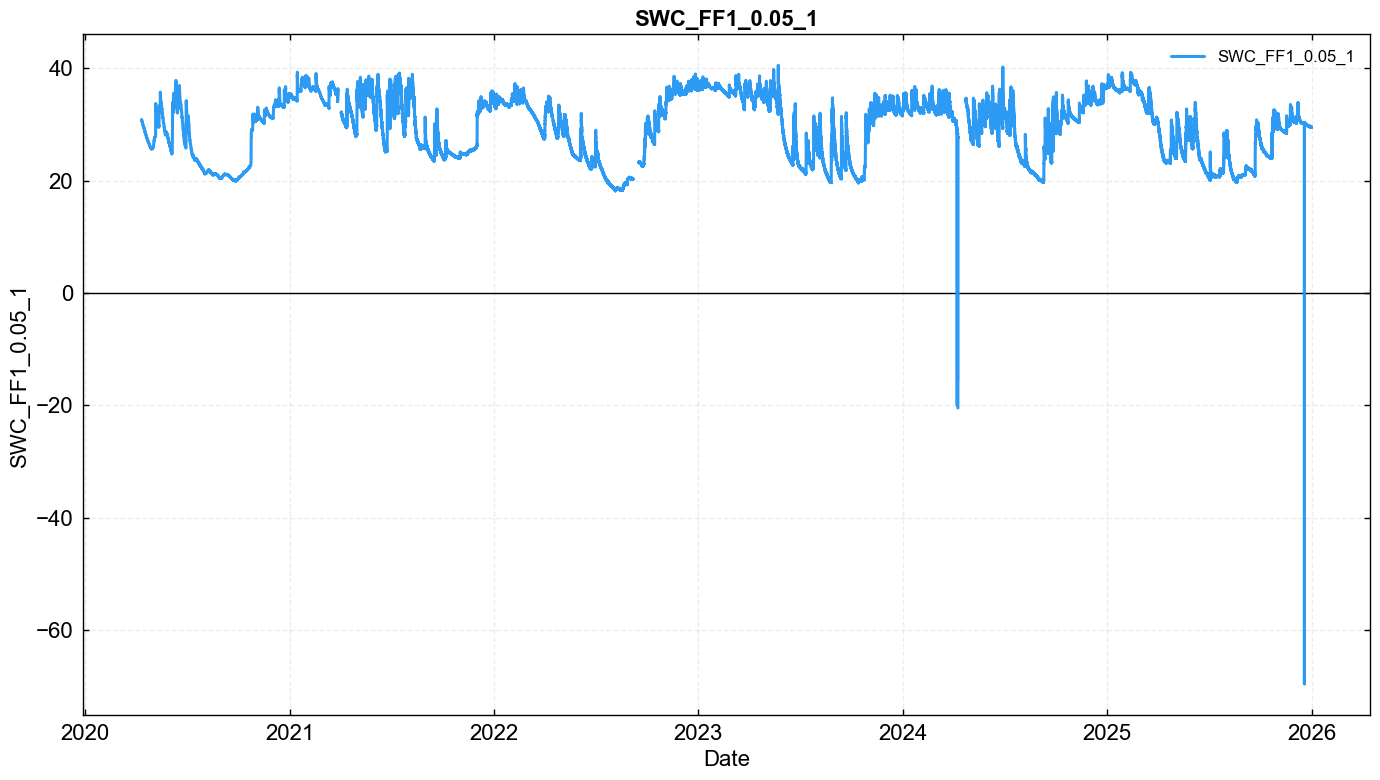

In [23]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What soil water content needs, and what it does not.** The series is smooth, strongly autocorrelated, and seasonally non-stationary: it ranges over more than 20 percentage points between a wet winter and a dry August, and the wet and dry extremes are the most interesting values in it, not the least trustworthy. Two consequences run through this whole section:

- **Never split day and night.** Every test below is run with `separate_daytime_nighttime=False`. Soil moisture has no meaningful diurnal cycle at these depths, so a day/night split would only halve the sample of each threshold.
- **Distribution-wide tests do not belong here.** A z-score over the whole record measures how far a value sits from the multi-year mean, which for this variable is a statement about the season, not about data quality. Those tests are listed further down, switched off, with the reasoning.

What is actually needed: the documented sensor fault (**manual removal**), the failed-read sentinels (**absolute limits**), spikes (**Hampel on the differenced series**), and the **missing-values** flag.

In [24]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable SWC_FF1_0.05_1 ...

Plot the current cleaned data at any point during detection:

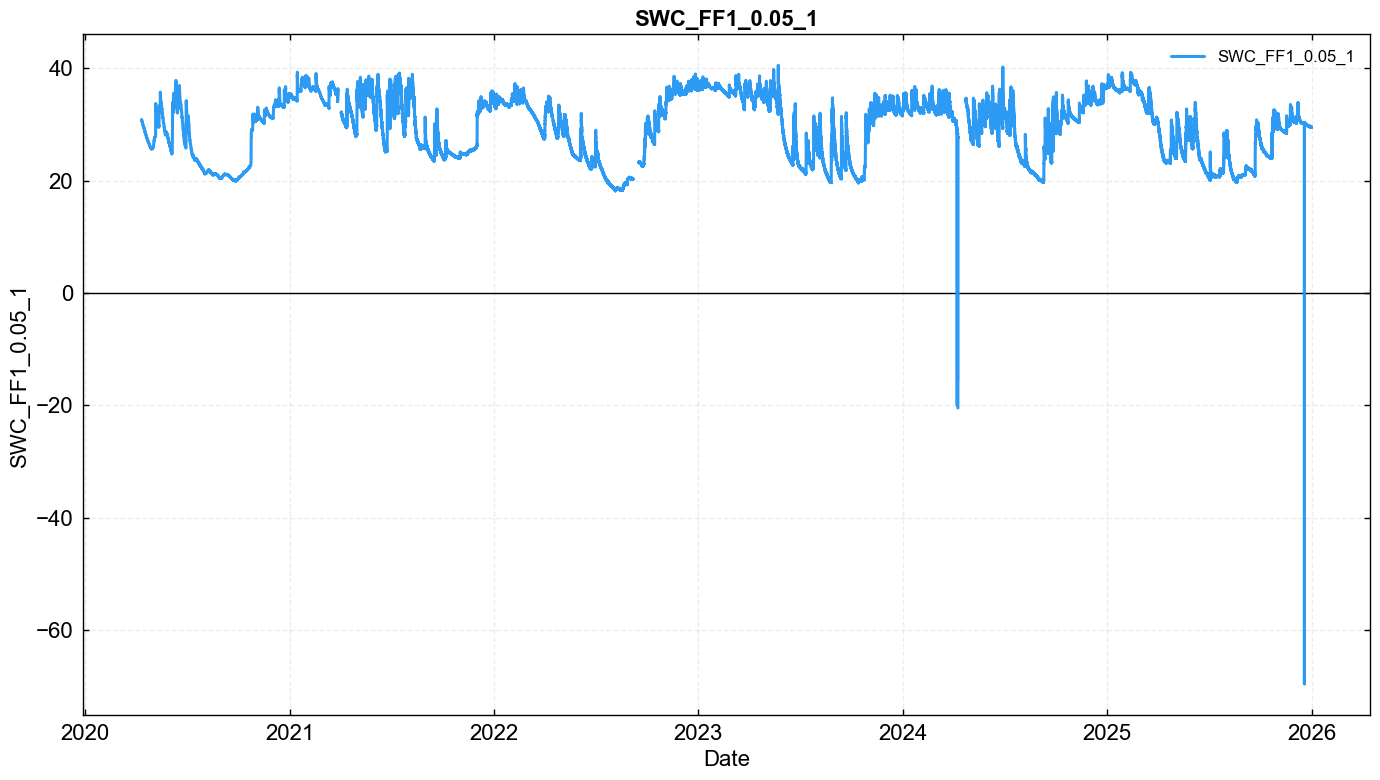

In [25]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal — known sensor failures, maintenance windows, etc. Give `[start, stop]` pairs and/or single timestamps.

In [26]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

> running ManualRemoval ...

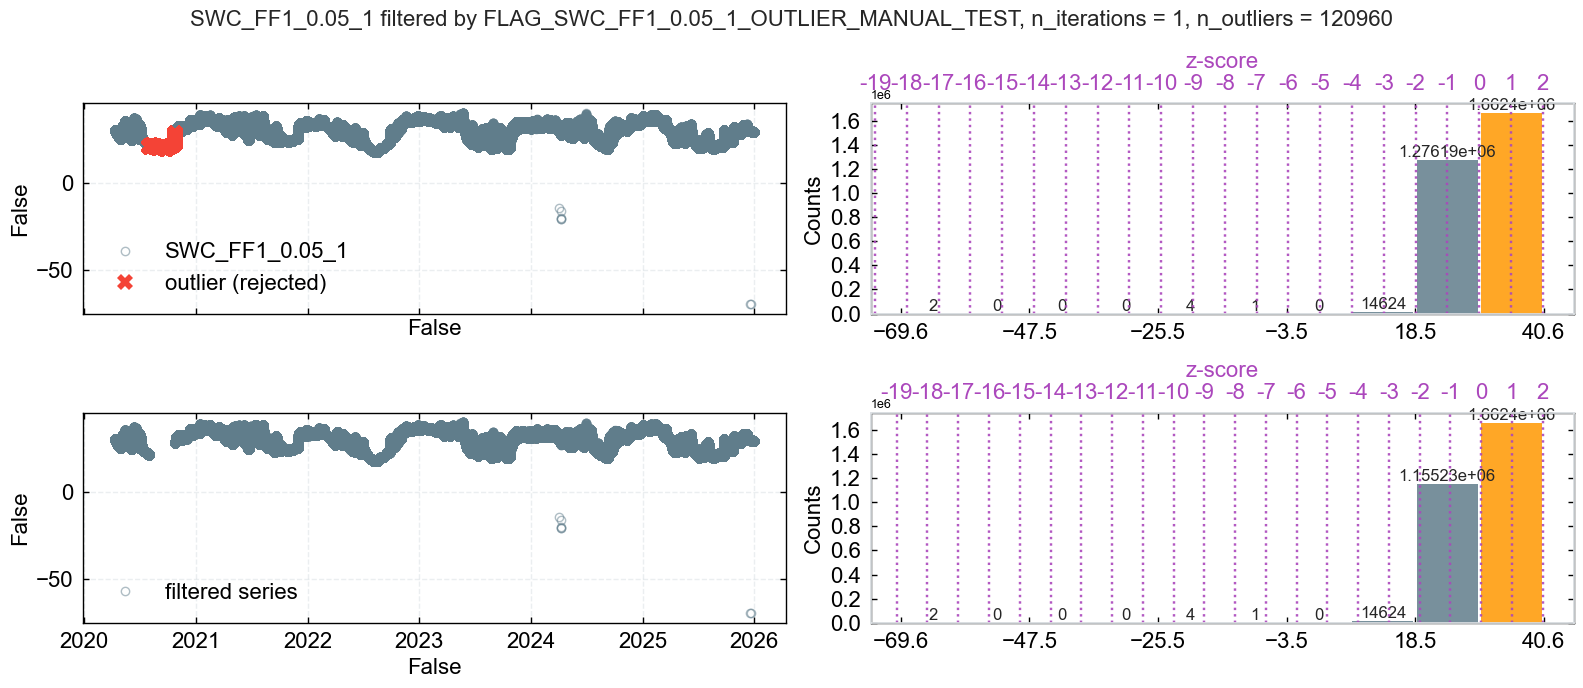

In [27]:
# Windows for THIS depth (5 cm). They are derived from this sensor's own evidence and
# must be re-derived for every other depth - see the closing note.
#
# Boundaries carry some slack on each side: screening runs internally on TIMESTAMP_MID
# while the cross-check above is on TIMESTAMP_END.
REMOVE_DATES = [
    # --- Aug-Oct 2020: the probe lost contact with the soil ------------------------
    # Not a fieldbook event and not visible in the values, which stay smooth and
    # in range the whole time. It shows up as a total loss of rain response:
    #   30 Aug 2020, 53.3 mm of rain in one day. Daily means before -> after:
    #     0.05 m  20.49 -> 20.51   (+0.02)   <- this sensor
    #     0.1 m   19.70 -> 27.07   (+7.4)
    #     0.2 m   23.84 -> 29.37   (+5.5)
    #     0.3 m   21.11 -> 27.24   (+6.1)
    #     0.5 m   19.26 -> 21.58   (+2.3)
    # Water cannot reach 50 cm without passing 5 cm. Over the whole window 242 mm of
    # rain fell and the sensor's largest single-day change was 0.18% VWC, while it
    # drifted smoothly from 20.0 to 22.7 - a probe reading its own drift in an air
    # gap, not the soil. The median summer response ratio for 2020 is 0.04 against
    # 0.97-2.61 in every other year.
    # Onset: last normal response 29 Jun 2020, first failed response 2 Aug 2020 (no
    # event > 10 mm in between, so the exact day cannot be pinned down). Recovery:
    # 23 Oct 2020, when 27 mm of rain closed the gap and the sensor jumped back onto
    # the profile within a day. Most likely the backfill settling and cracking around
    # a probe installed on 19 Mar 2020, in its first dry summer.
    # The fieldbook has nothing: no entry between 15 Jun and 15 Nov 2020 touches the
    # soil profile (see the adjudication cell above). This window rests on the physical
    # evidence alone - which is why the cross-check section exists.
    ['2020-08-01 00:00:00', '2020-10-24 00:00:00'],
]
if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this depth - skip the addflag cell below.')

In [28]:
if REMOVE_DATES:
    mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.05_1_OUTLIER_MANUAL_TEST to flag data

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for soil water content: every artefact in this record that is *not* the 2020 decoupling is a failed sensor read, and every failed read lands far outside the physical range.

In [29]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

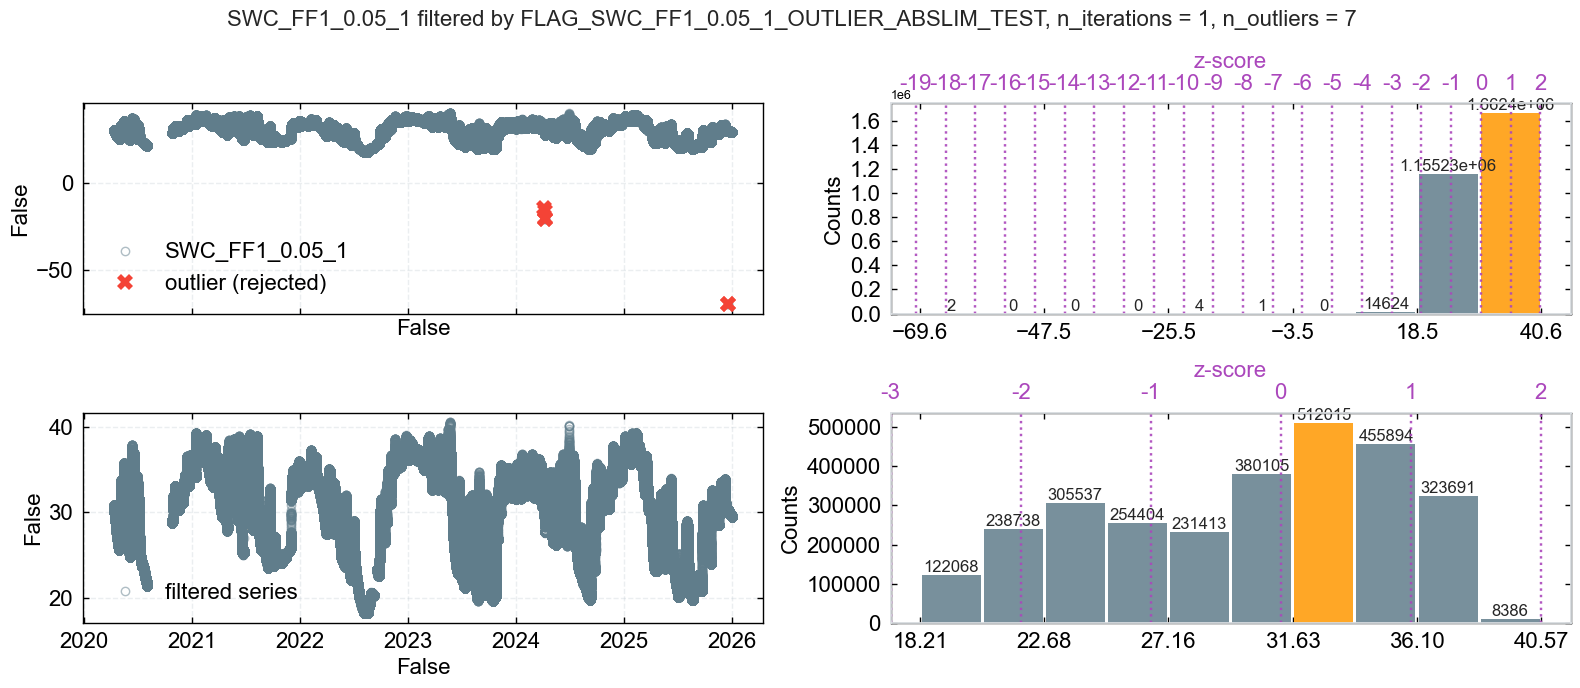

In [30]:
# Volumetric water content in %, so 0 is the hard physical floor. The upper limit is
# deliberately loose: the highest value ever recorded in this profile is 40.6%, well
# below any plausible porosity, so 60 can only fire on something unphysical.
# A failed SDI-12 read enters the record as that sensor's calibration polynomial
# evaluated at zero response, which lands at a fixed negative value per sensor
# (-14.4, -19.8, -69.6 ...) - hence a floor of 0 catches all of them and nothing else.
mscr.flag_outliers_abslim_test(minval=SWC_MIN, maxval=SWC_MAX, showplot=True, verbose=True)

In [31]:
mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.05_1_OUTLIER_ABSLIM_TEST to flag data

### Hampel filter (on the differenced series)
Sliding-window spike detection using the median absolute deviation — robust to spikes already inside the window. With `use_differencing=True` it works on the *rate of change*, which is the right target here: a real soil-moisture signal changes slowly and continuously, so a single record that jumps and comes straight back is an artefact whatever its absolute value. Day/night separation is off, for the reason given at the top of this section.

Run it, look at the preview, and only commit if it is removing spikes rather than the sharp (but real) wetting fronts that follow heavy rain.

In [32]:
if SHOW_PARAM_HELP:
    help(dv.outliers.Hampel)

> running Hampel ...

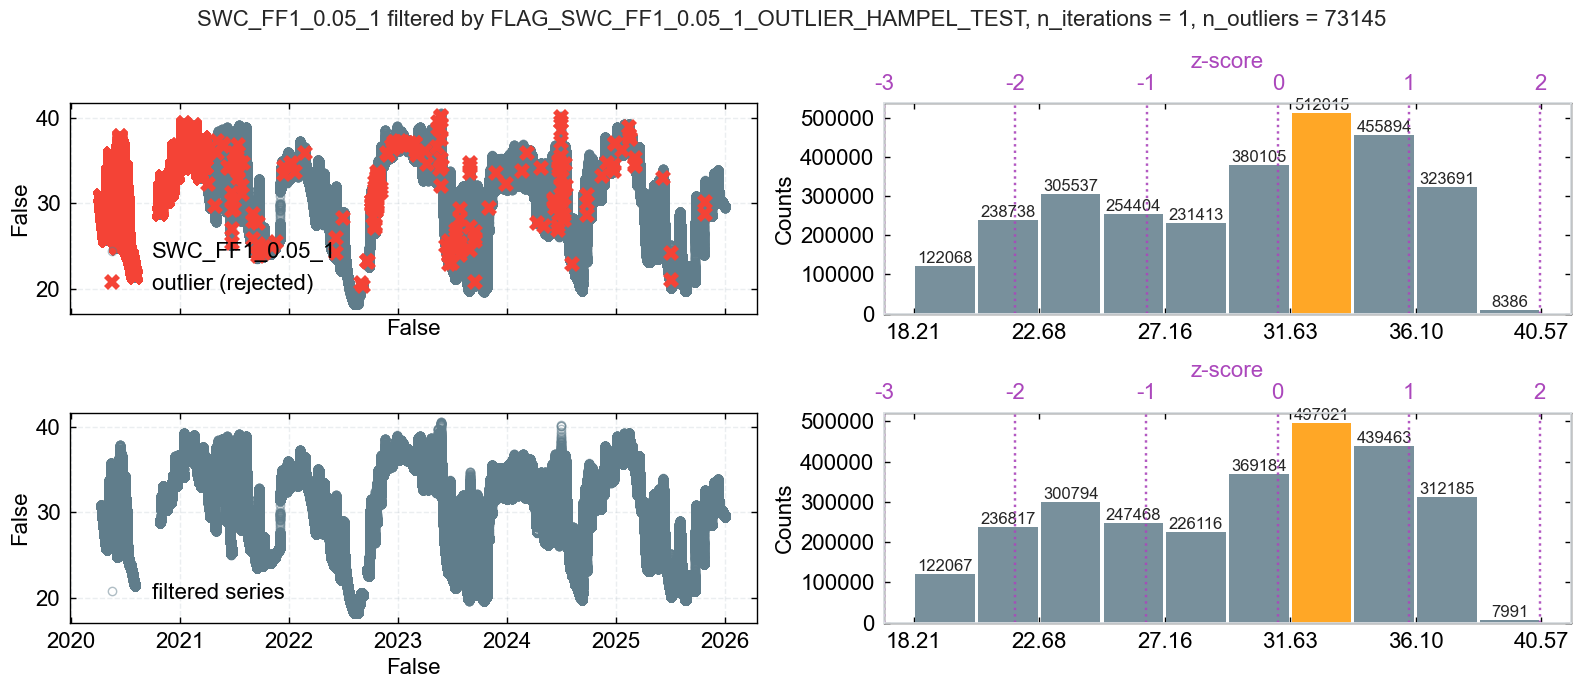

In [33]:
mscr.flag_outliers_hampel_test(
    window_length=60 * 24,  # one day of 1MIN records
    n_sigma=8, use_differencing=True, separate_daytime_nighttime=False,
    repeat=False, showplot=True, verbose=True,
)

In [34]:
mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.05_1_OUTLIER_HAMPEL_TEST to flag data

### Statistical outlier tests — not used here
The template's remaining tests (z-score, rolling z-score, local SD, increments z-score, local outlier factor, trim low) are **left switched off on purpose**:

- **z-score over the whole record** measures distance from the multi-year mean. For this variable that distance *is* the season: August 2022 and February 2021 sit at opposite ends of a 20-point range and both are correct. It would trim the extremes that matter most.
- **Rolling z-score / local SD** are better behaved but still fight the physics: the sharp wetting front after heavy rain is exactly the kind of local excursion they flag, and it is the most real feature in the series.
- **Increments z-score** is not comparable across this record's two eras — the upsampled 10MIN era has nine zero increments in every ten records (see *The raw record has two time resolutions*), so a threshold tuned on one era is meaningless in the other. The Hampel filter above covers the same failure mode more robustly.
- **Local outlier factor** is far too slow on 1MIN data and adds nothing that Hampel does not already catch.
- **Trim low** removes a fixed share of low values by construction. Nothing here justifies that.

If you still want to try one, the calls are below — run it, look at the preview plot, and only `mscr.addflag()` if it is genuinely removing artefacts.

In [35]:
# Optional, off by default - see the note above before enabling any of these.
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test — flags missing records so they are counted in the overall `QCF`.

In [36]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_SWC_FF1_0.05_1_MISSING_TEST, newly 
calculated from variable SWC_FF1_0.05_1, with flag 0 (good values) where SWC_FF1_0.05_1 is 
available, flag 2 (bad values) where SWC_FF1_0.05_1 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [37]:
mscr.finalize_outlier_detection()

#### Reports

In [38]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: SWC_FF1_0.05_1

...

1     SWC_FF1_0.05_1_MISSING                 0        2953218      0            100.00    0.00      
2953218/0/0

2     SWC_FF1_0.05_1_OUTLIER_MANUAL          120960   2832258      120960       95.90     4.10      
2832258/0/120960

3     SWC_FF1_0.05_1_OUTLIER_ABSLIM          7        2832251      120967       95.90     4.10      
2832251/0/120967

4     SWC_FF1_0.05_1_OUTLIER_HAMPEL          73145    2759106      194112       93.43     6.57      
2759106/0/194112

====================================================================================================
====================

In [39]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: SWC_FF1_0.05_1

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 4

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ SWC_FF1_0.05_1_OUTLIER_HAMPEL

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2880073 ( 97.5%) │     0 (  0.0%)  │ 73145 (  2.5%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [40]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: SWC_FF1_0.05_1

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2759106/2953218 (93.43%)

Data loss from QC:         194112/2953218 (6.57%)

Final data coverage:       2759106/3011590 (91.62% of potential)

======================================================================

#### Plots

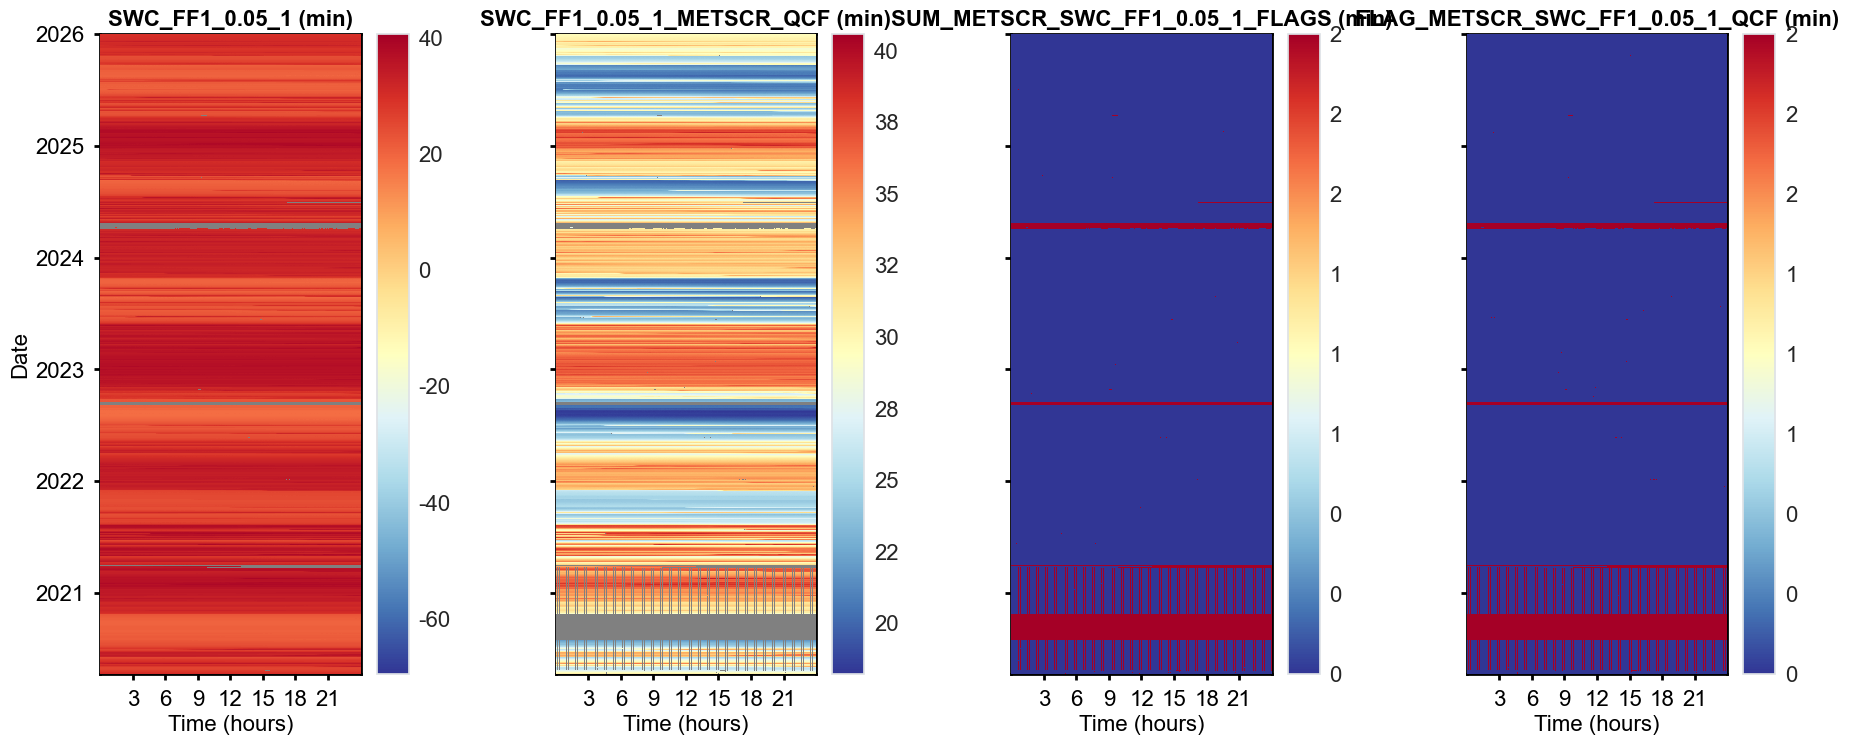

In [41]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil water content**, and all calls below stay commented out.

The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant — every one of them writes a value the sensor did not measure. For this variable there is nothing to correct *within* the series: a probe reading too high or too low is a calibration matter (soil-specific permittivity calibration), which cannot be fixed after the fact from the series itself, and the one real fault in this record was a decoupled probe, whose values are not correctable but simply wrong and already removed.

> ⚠️ In particular, do **not** clip to a minimum: the failed reads are already gone via absolute limits, and clipping would replace a missing measurement with a fabricated 0% — which reads as "bone dry soil" downstream.

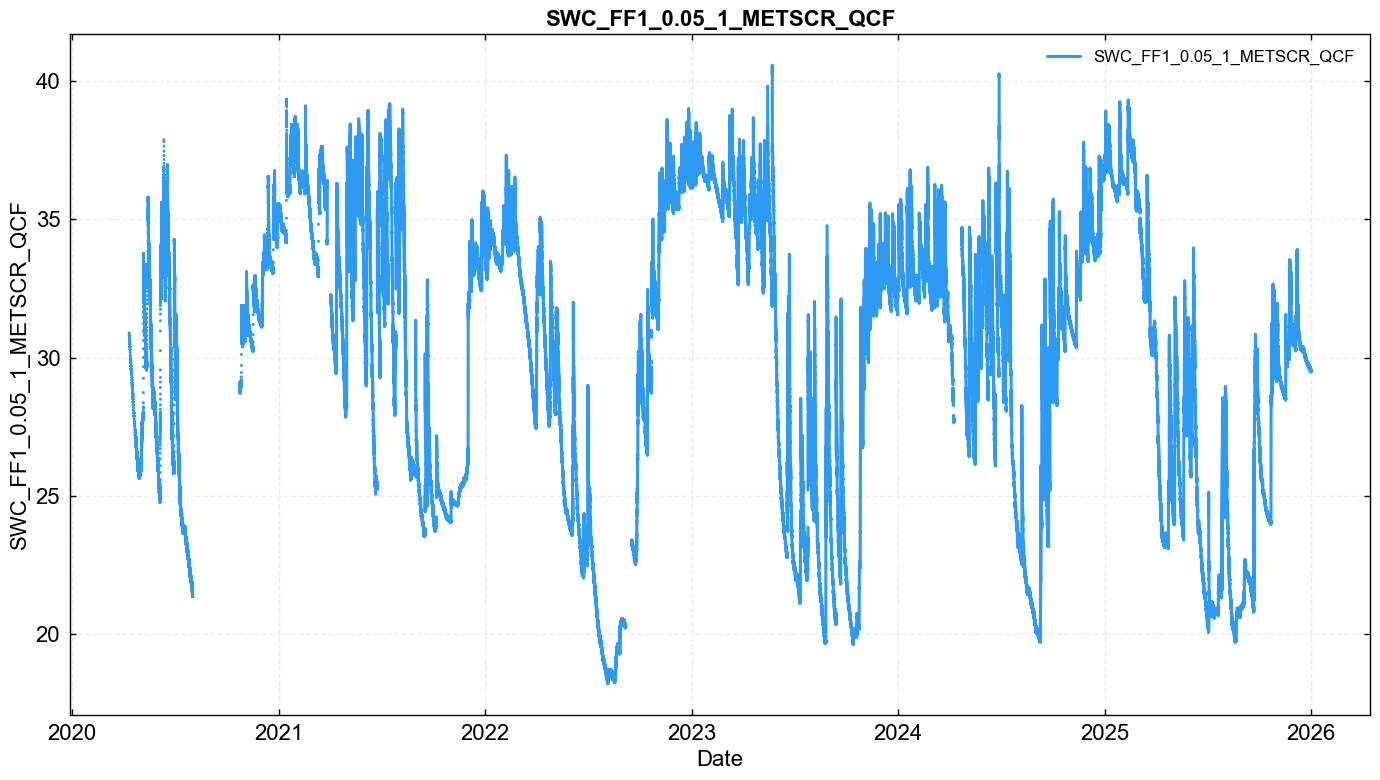

In [42]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). For soil water content there should be **no** dominant repeated value: a value appearing thousands of times in the 1MIN era would mean a stuck sensor. Frequent repeats *are* expected in the 2020-2021 part, where each 10MIN reading was back-filled across ten 1MIN slots.

In [43]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

--- SWC_FF1_0.05_1 (top 20 of 2759106 records) ---
SWC_FF1_0.05_1_METSCR_QCF
27.4    924
28.3    831
27.7    784
29.4    766
28.0    750
29.0    674
29.7    632
28.7    596
29.6    582
30.8    559
30.4    552
30.7    502
27.6    474
30.0    466
27.9    432
30.3    427
29.3    410
29.9    394
29.1    374
28.6    354
Name: count, dtype: int64


In [44]:
# All commented out on purpose - none of these apply to soil water content.
# mscr.correction_setto_max_threshold(threshold=60)
# mscr.correction_setto_min_threshold(threshold=0)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

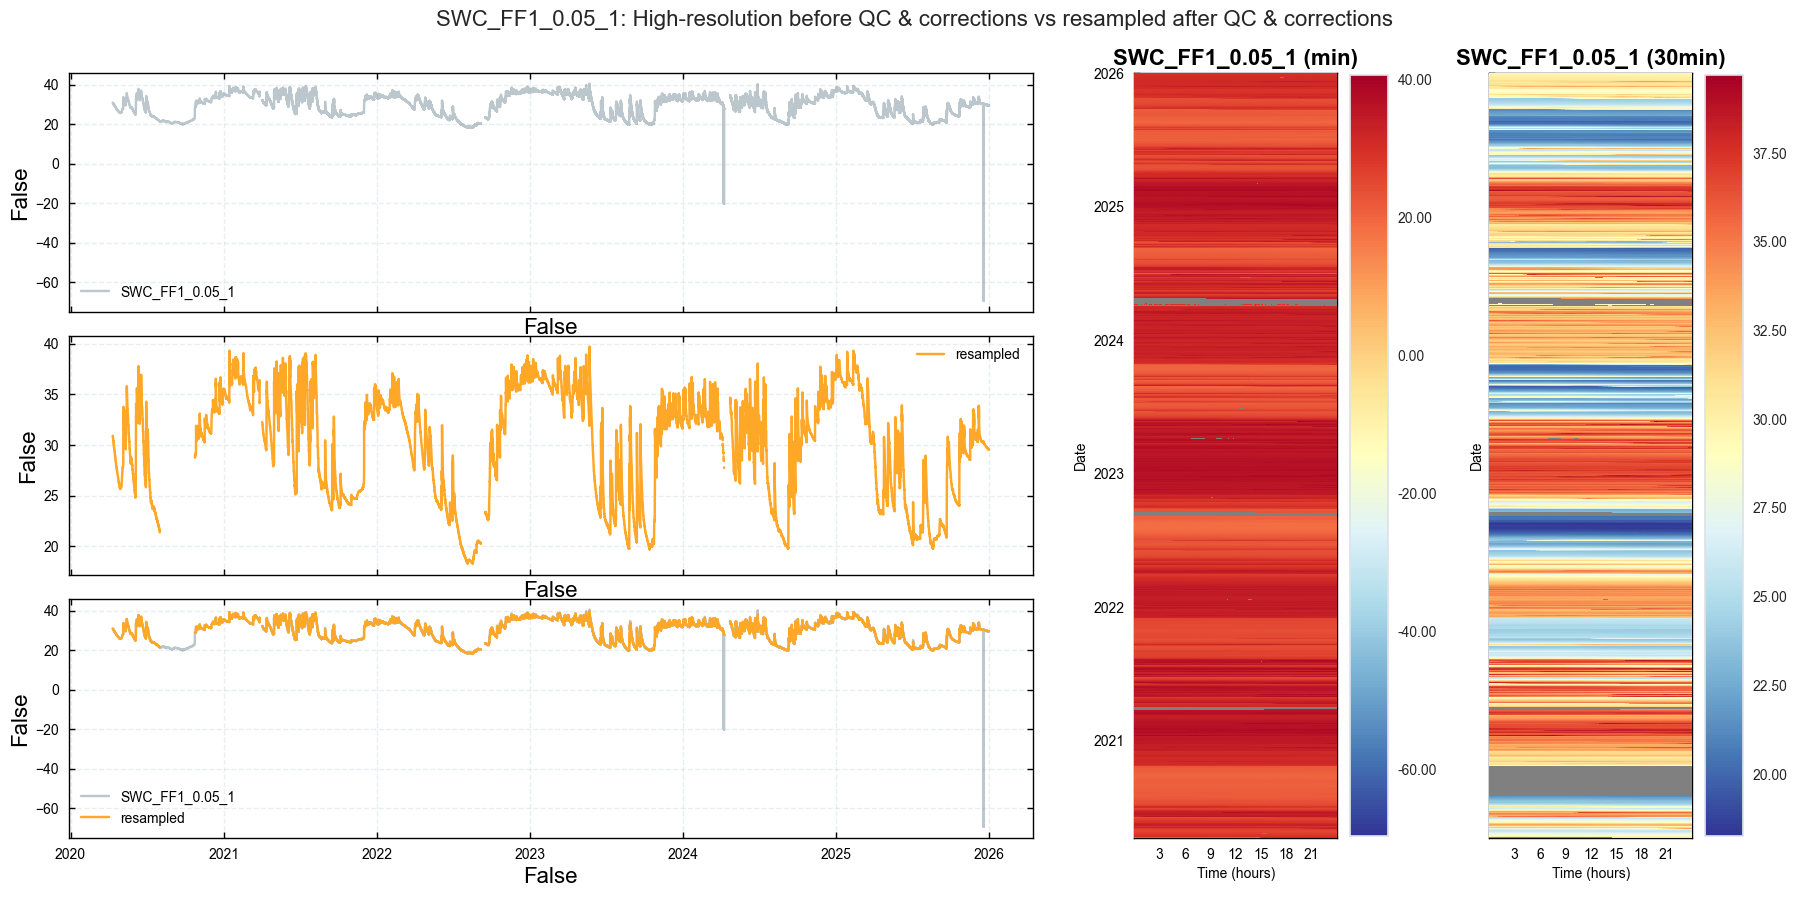

In [45]:
# mincounts_perc stays at the template default of .25, the opposite choice from the
# precipitation notebook. A 30MIN *mean* of a smooth state variable is well estimated
# from a quarter of the records, whereas a *sum* built from a quarter of the records
# under-reports by construction. Requiring near-complete coverage here would throw
# away good half-hours during the April 2024 bus trouble for no gain in accuracy.
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [46]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - SWC_FF1_0.05_1: 30min


### Re-check the screened product against the profile
The same comparison as before screening, now on the resampled 30MIN product. Screening should leave the agreement with the rest of the profile **no worse** than it was — if the correlation drops, a test removed real soil moisture rather than an artefact. It is expected to improve slightly here, because the removed 2020 window is exactly the period in which this sensor disagreed with the profile.

In [47]:
_screened = mscr.resampled_detailed[FIELD][FIELD]

_before = prof.resample('D').mean()
_after = _before.copy()
_after[FIELD] = _screened.resample('D').mean()

r_before = _before[FIELD].diff().corr(_before[COMPANIONS].mean(axis=1).diff())
r_after = _after[FIELD].diff().corr(_after[COMPANIONS].mean(axis=1).diff())
n_before = prof[FIELD].notna().sum()
n_after = _screened.notna().sum()

print(f'{"":18s} {"n 30MIN":>9s} {"r(increments)":>15s} {"mean [%]":>10s}')
print(f'{"before screening":18s} {n_before:9d} {r_before:15.3f} {prof[FIELD].mean():10.2f}')
print(f'{"after screening":18s} {n_after:9d} {r_after:15.3f} {_screened.mean():10.2f}')
print(f'{"removed":18s} {n_before - n_after:9d} '
      f'({(1 - n_after / n_before) * 100:.2f}% of the half-hours that had a value)')

if r_after < r_before - 0.01:
    print('\n(!) WARNING - agreement with the profile got worse. A test may have removed real data.')
else:
    print('\nOK - screening did not degrade agreement with the rest of the profile.')

                     n 30MIN   r(increments)   mean [%]
before screening       98538           0.736      29.52
after screening        94461           0.772      29.88
removed                 4077 (4.14% of the half-hours that had a value)

OK - screening did not degrade agreement with the rest of the profile.


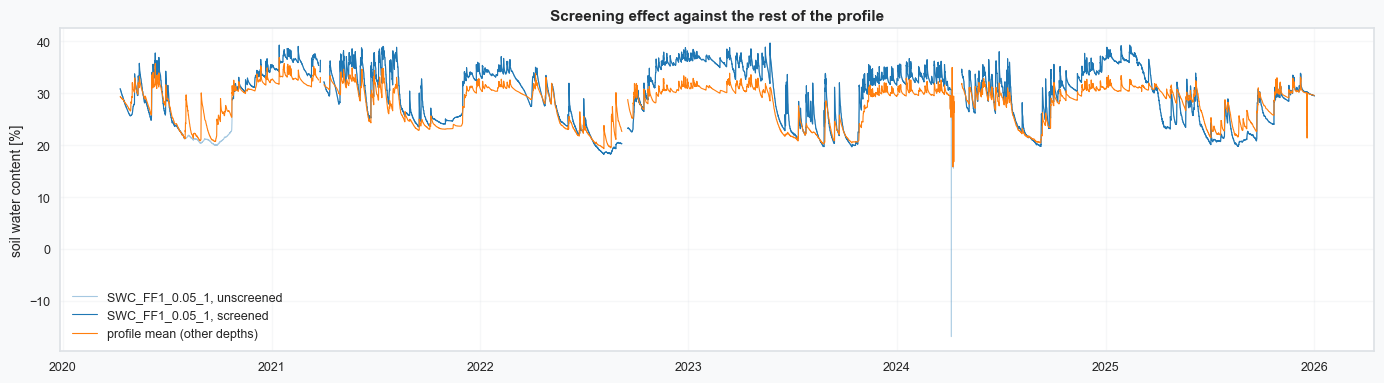

In [48]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof.index, prof[FIELD], label=f'{FIELD}, unscreened', color='tab:blue', alpha=.4, lw=.8)
ax.plot(_screened.index, _screened, label=f'{FIELD}, screened', color='tab:blue', lw=.8)
ax.plot(prof.index, prof[COMPANIONS].mean(axis=1), label='profile mean (other depths)',
        color='tab:orange', lw=.8)
ax.set_ylabel('soil water content [%]')
ax.set_title('Screening effect against the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

## ⬆️ Upload data to database

**Re-uploading overwrites the same variant — safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** — the delete removes it regardless of tags.

Only the target variable is uploaded. The companion depths were downloaded read-only for the cross-check and each has its own notebook.

In [49]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['SWC_FF1_0.05_1'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['SWC'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['SWC_FF1_0.05_1']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` — matching what you screened.

In [50]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.05_1'] from measurements 
['SWC'], data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

,SWC_FF1_0.05_1
TIMESTAMP_END,
2020-04-10 15:00:00,30.900000
2020-04-10 15:30:00,30.900000
2020-04-10 16:00:00,30.900000
2020-04-10 16:30:00,30.900000
2020-04-10 17:00:00,30.800000
...,...
2025-12-31 22:00:00,29.538065
2025-12-31 22:30:00,29.528240
2025-12-31 23:00:00,29.530094


In [51]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - SWC_FF1_0.05_1: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [52]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-21 22:04:28  (runtime 0:11:42)


***
### 📝 Notes for this variable
- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` — soil water content is a state, not a flux.
- **Units are volumetric %,** stored with `gain = 100` on a raw `m^3/m^3` reading. The database unit tag says `%` for both eras of this record; the magnitudes (18-41) agree with that, and the export is checked against it above.
- **Sensor history.** The FF1 profile is five **TEROS 12** probes installed on 19 Mar 2020 (the old EC-20 sensors were removed and trashed the same day) and first logged on 10 Apr 2020, which is where this record begins. The logger box was rebuilt on 24-26 Mar 2021, which changed the resolution from 10MIN to 1MIN but not the sensors. **Nothing before 2020-04-10 belongs to this series** — soil moisture up to that day lives under the old `SWC_M5_*` names (a different profile, different sensors, gain 1), and merging the two would be a splice of two instruments, not a continuation.
- **Two raw time resolutions** (10MIN then 1MIN) — see the dedicated section above for what diive does with them and what it means for the tests.
- **The first 11 days are coarse.** From 2020-04-10 to 2020-04-21 values arrive in steps of 0.1% VWC; a logger software change on 21 Apr 2020 moved them to full float precision. The values are usable throughout, but do not read fine structure into that fortnight — and expect the flat-run scan to fire there.
- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support, so a read that fails lands in the record as a fixed negative value (this sensor: −14.4, −19.8, −20.9, −64.6, −69.6). That is why absolute limits, not the missing-values flag, is the test that catches them, and why a floor of `0` is not optional.
- **The profile is the reference, and it is not a replicate set.** The depths differ in level and amplitude by design; only the *ordering* of the response is physically enforced (shallow wets first). Nothing from the companion depths is written into this series or uploaded.
- **Not a gap-filling source.** The companion depths and the precipitation product are used for comparison only.

***
### ⚠️ The one real fault: a decoupled probe, Aug-Oct 2020

This is the dominant quality issue for `SWC_FF1_0.05_1` and the reason this notebook cross-checks
against the profile at all. Between roughly **1 Aug and 23 Oct 2020** the sensor kept producing
smooth, in-range, plausibly drifting values while 242 mm of rain fell without moving it. Every
statistical outlier test passes those values; only the comparison with the deeper sensors and with
precipitation exposes them.

| | tower 0.05 m | 0.1 m | 0.2 m | 0.3 m | 0.5 m | rain |
|---|---|---|---|---|---|---|
| 2020-08-02 | +0.1 | +12.0 | +8.9 | +9.2 | +0.1 | 18.2 mm |
| 2020-08-30 | +0.1 | +9.9 | +7.9 | +7.5 | +5.9 | 53.3 mm |
| 2020-10-03 | +0.2 | +2.3 | +2.4 | +4.7 | 0.0 | 16.3 mm |
| 2020-10-23 | +6.3 | +3.2 | +5.2 | +4.8 | +7.1 | 26.6 mm |

(change in daily mean [% VWC] from the day before the event to the two days after)

The last row is the recovery: as soon as 27 mm of rain fell on 23 Oct the sensor jumped back onto the
profile and behaved normally for the remaining five years. The most likely cause is the backfill
settling and cracking away from the prongs during the first dry summer after installation, closed
again by heavy autumn rain. **The window is removed** in `REMOVE_DATES`; its boundaries are as tight
as the evidence allows (no rain event over 10 mm between 29 Jun and 2 Aug 2020, so the onset cannot
be dated more precisely than "in July").

**This is a depth-specific fault.** The rolling-agreement check finds nothing comparable in any other
year, and the same check must be run — and can find something different — for each of the other four
depths.

### 🔎 Fieldbook cross-check (GIN export `CH-LAE-laegeren-export_20260719.csv`)

The export is read in the *Adjudicate the candidates* cell above; this is the summary. Events that
explain something in the data, none of which needs a removal beyond what the tests already do:

| Data feature | Fieldbook entry |
|---|---|
| 0.1% value steps, 2020-04-10 → 2020-04-21, and every identical-value run over 3 h | 2020-04-21, "New datalogger software with two byte precision for the soil profile measurement (Teros 12 and 21)" — after it, full float precision |
| Failed reads stored as fixed negative numbers rather than gaps | 2020-04-10, the CR1000 firmware predates SDI-12 NaN support and was deliberately not updated ("thinking of the imminent system upgrade") |
| Gap 2021-03-24 → 2021-03-29 (in pieces), and the 10MIN → 1MIN change | FF1 logger box rebuilt, all components shut down 24 Mar, new CR1000 and program, data acquisition restarted 26 Mar |
| Gap 2022-09-06 → 2022-09-16 (10 d) | FF1 12 V DC-DC power supply failed; "the data is missing for 10 days (6th September to 16th September) due to power outage at the FF1", replaced 16 Sep |
| Gap 2023-06-15 (20 h) | "There is a problem with the power at ch-lae … the ff1 is [affected]. No system at ff1 was running for 'one day'"; "FF1 is running again" 16 Jun. (The main tower box replacement two days earlier is a separate, tower-side event.) |
| 2024-04-03 → 2024-04-23: degraded logging, stray 2/3/5/6-minute records, negative reads, then 14 d out | the 0.3 m probe was failing and "caused an interruption of the SDI12 communication of all sensors at the same port"; unplugged 23 Apr 2024, which is exactly when this record resumes |
| Negative reads on all five depths, 18-19 Dec 2025 | two remote logger-program uploads to the FF1 meteo logger on exactly those days ("Remotly uploaded new loggerprogram", then a windvane fix) |
| Missing hour on 2023-04-06 | 48 V power supply failed, exchanged with the backup from the hut |

**Unexplained:** two gaps have no fieldbook entry within ±3 days — **2024-06-29 17:20 →
2024-07-01 13:25** (44 h) and **2024-10-16 07:10 → 15:05** (8 h). The first is the *same* gap the
precipitation notebook flagged as unexplained, so it is a station-wide outage rather than anything to
do with the soil profile — still worth chasing.

Two further entries were checked and leave **no** trace in this series, which is worth recording so
nobody re-opens them:

- **The 23 Oct 2025 wind storm** brought a beech down onto the FF1 station: the mast is tilted, the
  TA/RH shelter shattered and the radiation sensors ended up near-vertical. Those are all
  above-ground sensors. The buried profile logged 1440 records/day throughout and all five depths
  wet up together with the storm rain — no gap, no step, nothing to remove. It will matter for the
  FF1 *meteo* variables, not for this one.
- **The 2023-06-30 timezone change** ("Changed the timezone from CEST to GMT+1") applies to
  `iDAQ_FF1_0_1`, the embedded PC that writes the eddy-covariance binaries, not to the CR1000 that
  produces this series — and the raw EC files were renamed accordingly on 3 Jul 2023. The soil
  timestamps are unaffected.

### ♻️ Reusing this notebook for the other depths

Copy this notebook to `SWC_{PROFILE}_<depth>_1_2020-2025.ipynb` and change **`DEPTH`** in
*User settings*. Everything else — field name, companion list, buckets, upload target — is derived
from it. Then work through these, in this order:

1. **Re-run the cross-check and re-derive `REMOVE_DATES`.** The 2020 window above belongs to the 5 cm
   probe alone. Delete it and put in what that depth's own rolling-agreement and rain-response
   checks show, then re-adjudicate against the fieldbook (update `CANDIDATES` to that depth's own
   scan output). If a depth has no documented fault, leave `REMOVE_DATES` empty — the two
   manual-removal cells are guarded and will skip themselves.
2. **Expect the rain-response test to weaken with depth.** A ratio near 0 is damning at 5 cm and
   unremarkable at 50 cm, where a summer event genuinely may not arrive at all. Read the *ordering*
   of the depths, not the absolute ratio.
3. **Two depths carry known faults, already in the fieldbook.** `0.3` failed in April 2024, was
   unplugged on 23 Apr 2024 and replaced on 4 Mar 2025 — but the replacement went in 40 cm down the
   slope because the old one could not be removed, and its level differs from the old one's by about
   3% VWC. That is a sensor change inside one field name, not a gap: screen the two eras with that
   in mind and say so in the notebook. `0.2` has an incident logged on 27 Jun 2025 stating the
   sensor "does not work regularly since 27.02", closed on 6 Jul 2025 with "the sensor is working
   fine" — so check 27 Feb → 6 Jul 2025 for that depth specifically. (The entry names `TS_FF1_02_1`,
   the co-located soil *temperature*, while being filed under the SWC device, so establish from the
   data which of the two it actually was.)
4. **Do not carry over the absolute limits blindly** either, though `[0, 60]` is physical and should
   hold for every depth at this site. Check the value range printed by the cross-check first.